# Zarr Chunk Size Benchmark

This notebook benchmarks zarr dataset loading performance across different chunk sizes and action horizons.

In [14]:
import subprocess
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuration
BASE_PATH = Path("/home/ryan/Code/EgoVerse/egomimic/rldb/zarr/zarr/dynamic")
BENCHMARK_SCRIPT = Path("/home/ryan/Code/EgoVerse/egomimic/rldb/zarr/benchmark_forward_pass.py")

# Chunk sizes (timesteps per chunk)
CHUNK_SIZES = [100, 250, 500, 9999]

# Action horizons to test
ACTION_HORIZONS = [1, 25, 50, 100, 250, 500]

# Benchmark parameters
NUM_SAMPLES = 5000
BATCH_SIZE = 32
NUM_WORKERS = 10
WARMUP = 10
SIMULATED_COMPUTE = 0  # No simulated compute - measure pure loading speed

In [15]:
def run_benchmark(zarr_path: Path, action_horizon: int) -> dict:
    """Run benchmark_forward_pass.py and parse the results."""
    cmd = [
        "python", str(BENCHMARK_SCRIPT),
        "--zarr-path", str(zarr_path),
        "--skip-lerobot",
        "--dynamic-chunks",
        "--action-horizon", str(action_horizon),
        "--num-samples", str(NUM_SAMPLES),
        "--batch-size", str(BATCH_SIZE),
        "--num-workers", str(NUM_WORKERS),
        "--warmup", str(WARMUP),
        "--simulated-compute", str(SIMULATED_COMPUTE),
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    output = result.stdout + result.stderr
    
    # Parse the results table
    # Looking for lines like:
    # | Batches/sec                | 123.4 |
    # | Avg load time/batch (ms)   | 5.6 |
    # | Avg overhead/batch (ms)    | 7.8 |
    # | Total time (s)             | 12.34 |
    
    metrics = {}
    
    # Parse batches/sec
    match = re.search(r"Batches/sec\s*\|\s*([\d.]+)", output)
    if match:
        metrics["batches_per_sec"] = float(match.group(1))
    
    # Parse avg load time per batch (ms)
    match = re.search(r"Avg load time/batch \(ms\)\s*\|\s*([\d.]+)", output)
    if match:
        metrics["avg_load_time_ms"] = float(match.group(1))
    
    # Parse avg overhead per batch (ms)
    match = re.search(r"Avg overhead/batch \(ms\)\s*\|\s*([\d.]+)", output)
    if match:
        metrics["avg_overhead_ms"] = float(match.group(1))
    
    # Parse total time (s)
    match = re.search(r"Total time \(s\)\s*\|\s*([\d.]+)", output)
    if match:
        metrics["total_time_sec"] = float(match.group(1))
    
    # Parse samples processed
    match = re.search(r"Samples processed\s*\|\s*([\d,]+)", output)
    if match:
        metrics["samples_processed"] = int(match.group(1).replace(",", ""))
    
    return metrics

In [16]:
# Run all benchmarks
results = []

total_runs = len(CHUNK_SIZES) * len(ACTION_HORIZONS)
current_run = 0

for chunk_size in CHUNK_SIZES:
    zarr_path = BASE_PATH / f"{chunk_size}ts"
    
    if not zarr_path.exists():
        print(f"Warning: {zarr_path} does not exist, skipping...")
        continue
    
    for action_horizon in ACTION_HORIZONS:
        current_run += 1
        print(f"[{current_run}/{total_runs}] Running benchmark: chunk_size={chunk_size}, action_horizon={action_horizon}")
        
        metrics = run_benchmark(zarr_path, action_horizon)
        
        if metrics:
            metrics["chunk_size"] = chunk_size
            metrics["action_horizon"] = action_horizon
            results.append(metrics)
            print(f"  -> batches/sec: {metrics.get('batches_per_sec', 'N/A'):.1f}")
        else:
            print(f"  -> Failed to parse results")

print(f"\nCompleted {len(results)} benchmark runs.")

[1/24] Running benchmark: chunk_size=100, action_horizon=1
  -> batches/sec: 5.9
[2/24] Running benchmark: chunk_size=100, action_horizon=25
  -> batches/sec: 5.5
[3/24] Running benchmark: chunk_size=100, action_horizon=50
  -> batches/sec: 5.6
[4/24] Running benchmark: chunk_size=100, action_horizon=100
  -> batches/sec: 5.5
[5/24] Running benchmark: chunk_size=100, action_horizon=250
  -> batches/sec: 5.4
[6/24] Running benchmark: chunk_size=100, action_horizon=500
  -> batches/sec: 5.1
[7/24] Running benchmark: chunk_size=250, action_horizon=1
  -> batches/sec: 5.8
[8/24] Running benchmark: chunk_size=250, action_horizon=25
  -> batches/sec: 6.0
[9/24] Running benchmark: chunk_size=250, action_horizon=50
  -> batches/sec: 6.0
[10/24] Running benchmark: chunk_size=250, action_horizon=100
  -> batches/sec: 5.7
[11/24] Running benchmark: chunk_size=250, action_horizon=250
  -> batches/sec: 5.8
[12/24] Running benchmark: chunk_size=250, action_horizon=500
  -> batches/sec: 6.0
[13/24] R

In [17]:
# Create DataFrame from results
df = pd.DataFrame(results)
df = df.sort_values(["chunk_size", "action_horizon"])
print(f"Results DataFrame shape: {df.shape}")
df.head(10)

Results DataFrame shape: (24, 7)


,batches_per_sec,avg_load_time_ms,avg_overhead_ms,total_time_sec,samples_processed,chunk_size,action_horizon
0,5.9,170.3,170.5,26.77,5024,100,1
1,5.5,181.0,181.2,28.45,5024,100,25
2,5.6,177.8,177.8,27.91,5024,100,50
3,5.5,182.9,183.1,28.74,5024,100,100
4,5.4,184.8,185.0,29.04,5024,100,250
5,5.1,195.6,195.8,30.74,5024,100,500
6,5.8,171.4,171.6,26.94,5024,250,1
7,6.0,166.6,166.6,26.16,5024,250,25
8,6.0,167.6,167.6,26.32,5024,250,50
9,5.7,174.2,174.2,27.34,5024,250,100


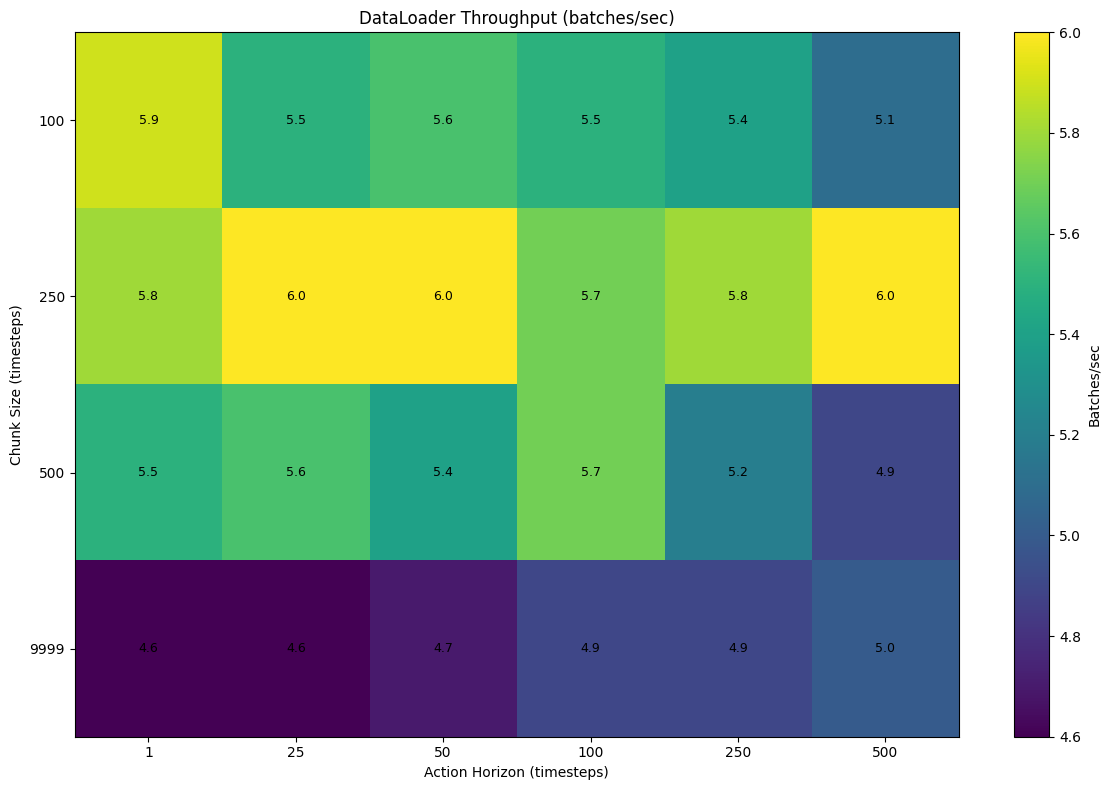

In [18]:
# Create heatmap of batches/sec
pivot = df.pivot(index="chunk_size", columns="action_horizon", values="batches_per_sec")

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")

# Set labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Action Horizon (timesteps)")
ax.set_ylabel("Chunk Size (timesteps)")
ax.set_title("DataLoader Throughput (batches/sec)")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Batches/sec")

# Add text annotations
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            text_color = "white" if val < pivot.values.max() * 0.5 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", color=text_color, fontsize=9)

plt.tight_layout()
plt.show()

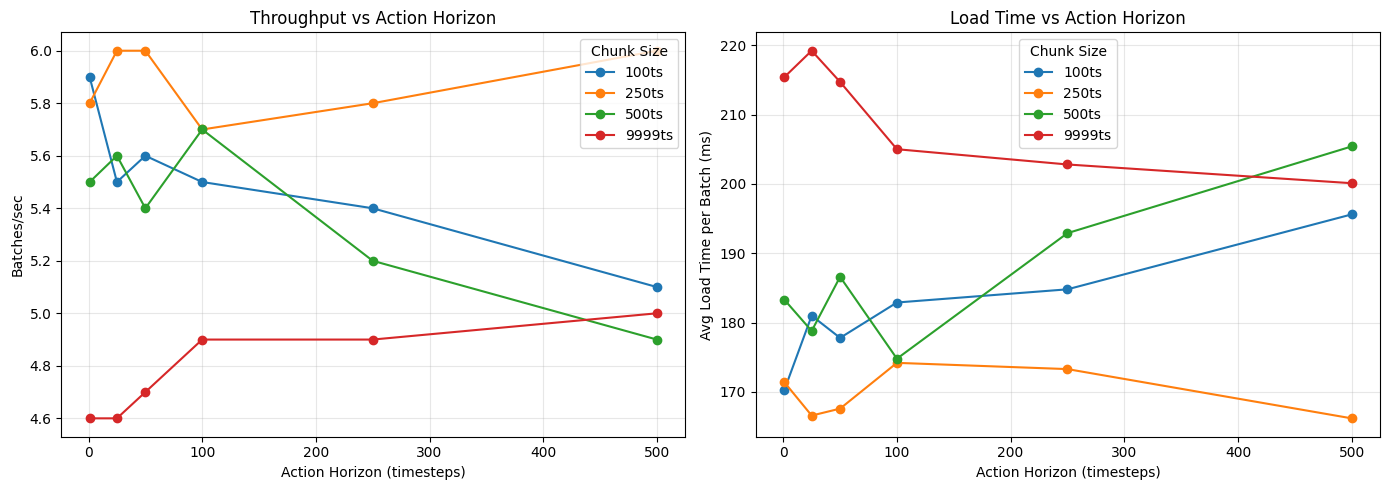

In [19]:
# Line plots: Batches/sec vs Action Horizon (one line per chunk size)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Batches/sec vs action horizon
ax1 = axes[0]
for chunk_size in CHUNK_SIZES:
    subset = df[df["chunk_size"] == chunk_size]
    if not subset.empty:
        ax1.plot(subset["action_horizon"], subset["batches_per_sec"], 
                 marker="o", label=f"{chunk_size}ts")

ax1.set_xlabel("Action Horizon (timesteps)")
ax1.set_ylabel("Batches/sec")
ax1.set_title("Throughput vs Action Horizon")
ax1.legend(title="Chunk Size", loc="best")
ax1.grid(True, alpha=0.3)

# Plot 2: Avg load time vs action horizon
ax2 = axes[1]
for chunk_size in CHUNK_SIZES:
    subset = df[df["chunk_size"] == chunk_size]
    if not subset.empty:
        ax2.plot(subset["action_horizon"], subset["avg_load_time_ms"], 
                 marker="o", label=f"{chunk_size}ts")

ax2.set_xlabel("Action Horizon (timesteps)")
ax2.set_ylabel("Avg Load Time per Batch (ms)")
ax2.set_title("Load Time vs Action Horizon")
ax2.legend(title="Chunk Size", loc="best")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Summary statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

# Best overall configuration
best_idx = df["batches_per_sec"].idxmax()
best = df.loc[best_idx]
print(f"\nBest overall configuration:")
print(f"  Chunk size: {best['chunk_size']} timesteps")
print(f"  Action horizon: {best['action_horizon']} timesteps")
print(f"  Batches/sec: {best['batches_per_sec']:.1f}")
print(f"  Avg load time: {best['avg_load_time_ms']:.1f} ms")

# Worst overall configuration
worst_idx = df["batches_per_sec"].idxmin()
worst = df.loc[worst_idx]
print(f"\nWorst overall configuration:")
print(f"  Chunk size: {worst['chunk_size']} timesteps")
print(f"  Action horizon: {worst['action_horizon']} timesteps")
print(f"  Batches/sec: {worst['batches_per_sec']:.1f}")
print(f"  Avg load time: {worst['avg_load_time_ms']:.1f} ms")

# Speedup
speedup = best["batches_per_sec"] / worst["batches_per_sec"]
print(f"\nSpeedup (best vs worst): {speedup:.1f}x")

# Best chunk size for each action horizon
print(f"\nBest chunk size for each action horizon:")
for ah in ACTION_HORIZONS:
    subset = df[df["action_horizon"] == ah]
    if not subset.empty:
        best_for_ah = subset.loc[subset["batches_per_sec"].idxmax()]
        print(f"  Action horizon {ah:>3}: chunk_size={int(best_for_ah['chunk_size']):>4}ts -> {best_for_ah['batches_per_sec']:.1f} batches/sec")

SUMMARY STATISTICS

Best overall configuration:
  Chunk size: 250.0 timesteps
  Action horizon: 25.0 timesteps
  Batches/sec: 6.0
  Avg load time: 166.6 ms

Worst overall configuration:
  Chunk size: 9999.0 timesteps
  Action horizon: 1.0 timesteps
  Batches/sec: 4.6
  Avg load time: 215.4 ms

Speedup (best vs worst): 1.3x

Best chunk size for each action horizon:
  Action horizon   1: chunk_size= 100ts -> 5.9 batches/sec
  Action horizon  25: chunk_size= 250ts -> 6.0 batches/sec
  Action horizon  50: chunk_size= 250ts -> 6.0 batches/sec
  Action horizon 100: chunk_size= 250ts -> 5.7 batches/sec
  Action horizon 250: chunk_size= 250ts -> 5.8 batches/sec
  Action horizon 500: chunk_size= 250ts -> 6.0 batches/sec


In [21]:
base = BASE_PATH / "benchmark_results.csv"

def next_available_csv(path: Path) -> Path:
    if not path.exists():
        return path
    stem, suffix = path.stem, path.suffix
    i = 1
    while True:
        candidate = path.with_name(f"{stem}_{i}{suffix}")
        if not candidate.exists():
            return candidate
        i += 1

output_csv = next_available_csv(base)
df.to_csv(output_csv, index=False)
print(f"Results saved to: {output_csv}")

Results saved to: /home/ryan/Code/EgoVerse/egomimic/rldb/zarr/zarr/dynamic/benchmark_results_1.csv
